In [1]:
import sys,os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glob

In [2]:
# set this up to point to the libararies directory in ml-holodec
dirP_str = os.path.join(os.environ['HOME'], 
                    'PythonScripts',
                    'Optics')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)

In [3]:
import MieLibrary as mie

In [4]:
cset_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/CSET/","*.nc"))
cset_loc_tag = "RWOOU"

socrates_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/SOCRATES/","*.nc"))
soc_loc_tag = "CVIU"

hippo1_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-1","*.nc"))
hippo1_loc_tag = "RWI"

hippo2_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-2","*.nc"))
hippo2_loc_tag = "RWI"

hippo3_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-3","*.nc"))
hippo3_loc_tag = "RWI"

hippo4_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-4","*.nc"))
hippo4_loc_tag = "RWI"

hippo5_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-5","*.nc"))
hippo5_loc_tag = "RWI"

In [17]:
# wavelen_lst = [1064e-9, 532e-9, 355e-9,]
# wavelen_color = ['tab:red', 'tab:green', 'tab:purple']

# wavelen_lst = [1064e-9, 710e-9, 800e-9, 532e-9, 400e-9, 355e-9,] # 355, 400, 532, 710, 800, and 1064: Veselovskii et all 2002
wavelen_lst = [355e-9,]
# wavelen_color = ['tab:red', 'r', 'tab:orange', 'tab:green', 'b', 'tab:purple']
wavelen_color = ['tab:purple']

# real_index_refrac_lst = [1.3, 1.35, 1.4, 1.45, 1.5, 1.55, 1.6]
# imag_index_refrac_lst = [0.0, 0.02, 0.04, 0.06]
real_index_refrac_lst = [1.3,]
imag_index_refrac_lst = [0.0,]

In [19]:
number_conc_lst = []
mean_r_lst = []
mean_r_2_lst = []
mean_r_3_lst = []
mean_ln_r_lst = []
std_ln_r_lst = []
beta_coef_lst = []
alpha_coef_lst = []
file_name_lst = []
proj_name_lst = []

aircraft_vars = ['GGLAT','GGLON','GGALT','Time','RHUM','THETA']
aircraft_vars_dct = {}
for var in aircraft_vars:
    aircraft_vars_dct[var] = []
aircraft_vars_attrs = {}

# postfix = 'RWOOU'  # CSET
# postfix = 'CVIU'   # SOCRATES
# postfix = 'RWI'  # HIPPO-1, HIPPO-2, HIPPO-3, HIPPO-4, HIPPO-5

# TODO also read in GGLAT, GGLON, GGALT

# file_lst = cset_lst
# file_lst = socrates_lst[4:5]
# file_lst = hippo1_lst
# file_lst = hippo2_lst
# file_lst = hippo4_lst
# file_lst = hippo5_lst

# project_file_lst = [hippo1_lst, hippo2_lst, hippo3_lst, hippo4_lst, hippo5_lst]
# # project_str_lst = ['HIPPO-1', 'HIPPO-2', 'HIPPO-3', 'HIPPO-4', 'HIPPO-5',]
# postfix_lst = [hippo1_loc_tag, hippo2_loc_tag, hippo3_loc_tag, hippo4_loc_tag, hippo5_loc_tag]

# project_file_lst = [socrates_lst, ]
# project_str_lst = ['SOCRATES',]
# postfix_lst = [soc_loc_tag,]

project_file_lst = [socrates_lst[3:4], hippo5_lst[3:4]]
project_str_lst = ['SOCRATES','HIPPO-5',]
postfix_lst = [soc_loc_tag, hippo5_loc_tag]


load_params = True

for project_idx, file_lst in enumerate(project_file_lst):
    postfix = postfix_lst[project_idx]
    project_str = project_str_lst[project_idx]

    for fidx,file in enumerate(file_lst):
        ds = xr.open_dataset(file)
        load_file = True
        
        if load_params:
            # run all the initial calculations
            try:
                part_diam = ds['CUHSAS_'+postfix].attrs['CellSizes']*1e-6
                # load_params = False
                r_arr = part_diam/2
                ang_arr = np.linspace(0,500e-6,100)
                dang=np.diff(ang_arr)
                solid_angle = 2*np.pi*np.trapz(np.sin(ang_arr),ang_arr)
                r_mat, ang_mat = np.meshgrid(r_arr,ang_arr)
        
                sig_pi = np.zeros((len(wavelen_lst), len(real_index_refrac_lst), len(imag_index_refrac_lst), r_arr.size))
                sig_e = np.zeros((len(wavelen_lst), len(real_index_refrac_lst), len(imag_index_refrac_lst), r_arr.size))
                
                for wl_idx, wavelen in enumerate(wavelen_lst):
                    for re_idx, real_index in enumerate(real_index_refrac_lst):
                        for im_idx, imag_index in enumerate(imag_index_refrac_lst):
                            index_refrac = real_index+1j*imag_index
                            k_num = 2*np.pi/wavelen
                            for r_idx,r_val in enumerate(r_arr):
                                x_val = 2*np.pi*r_val/wavelen  # particle size parameter
                                Fmat = mie.Mie_PhaseMatrix(index_refrac, x_val, np.pi+ang_arr)
                                sig_pi[wl_idx,re_idx,im_idx,r_idx] = np.real(1/k_num**2*2*np.pi*np.trapz(Fmat[0,:]*np.sin(ang_arr),ang_arr)) # backscatter
                                sig_e[wl_idx,re_idx,im_idx,r_idx] = np.real(mie.CrossSections(index_refrac,x_val)[0])*(np.pi*r_val**2)/2  # extinction
            except KeyError:
                load_file = False
                print("Cannot load " + file)
    
        # skip loading the data if there is no UHSAS data
        if load_file:
            # dataset calculations
            beta_coef = np.zeros((len(wavelen_lst), len(real_index_refrac_lst), len(imag_index_refrac_lst), ds['Time'].size))
            alpha_coef = np.zeros((len(wavelen_lst), len(real_index_refrac_lst), len(imag_index_refrac_lst), ds['Time'].size))
            for idx in range(len(wavelen_lst)):
                for re_idx, _ in enumerate(real_index_refrac_lst):
                    for im_idx, _ in enumerate(imag_index_refrac_lst):
                        beta_coef[idx,re_idx,im_idx,:] = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*1e6*sig_pi[idx,re_idx,im_idx,:][np.newaxis,:],axis=1)/solid_angle
                        alpha_coef[idx,re_idx,im_idx,:] = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*1e6*sig_e[idx,re_idx,im_idx,:][np.newaxis,:],axis=1)
            number_conc = np.trapz(ds['CUHSAS_'+postfix].values.squeeze(),axis=1)
            
            mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
            mean_r_2 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)/number_conc
            mean_r_3 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/number_conc
            mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
            std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
        
            valid_idx = np.where(number_conc > 0)  # locate and only use cases where the concentration is > 0
            for var in aircraft_vars_dct:
                aircraft_vars_dct[var].append(ds[var].values[valid_idx[0]])
                aircraft_vars_attrs[var] = ds[var].attrs
        
            beta_coef_lst.append(beta_coef[:,:,:,valid_idx[0]])
            alpha_coef_lst.append(alpha_coef[:,:,:,valid_idx[0]])
            number_conc_lst.append(number_conc[valid_idx[0]])
            mean_r_lst.append(mean_r[valid_idx[0]])
            mean_r_2_lst.append(mean_r_2[valid_idx[0]])
            mean_r_3_lst.append(mean_r_3[valid_idx[0]])
            mean_ln_r_lst.append(mean_ln_r[valid_idx[0]])
            std_ln_r_lst.append(std_ln_r[valid_idx[0]])
            file_name_lst.append([file.split(os.sep)[-1]]*len(valid_idx[0]))
            proj_name_lst.append([project_str]*len(valid_idx[0]))
            # file_name_lst.append(file.split(os.sep)[-1])
            # proj_name_lst.append(project_str)

/h/eol/mhayman/PythonScripts/Optics/MieLibrary.py:169: ComplexWarning: Casting complex values to real discards the imaginary part
  phi[n-1] = (2*n+3)*phi[n]/rho - phi[n+1]
/tmp/ipykernel_943549/2505110420.py:94: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_943549/2505110420.py:95: RuntimeWarning: invalid value encountered in divide
  mean_r_2 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)/number_conc
/tmp/ipykernel_943549/2505110420.py:96: RuntimeWarning: invalid value encountered in divide
  mean_r_3 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/number_conc
/tmp/ipykernel_943549/2505110420.py:97: RuntimeWarning: invalid value encountered in divide
  mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
/tmp/ipykernel_943549/2505110420.py:98: 

In [21]:
beta_coef_lst[0].shape

(1, 1, 1, 8545)

In [30]:
lst_idx = 0
b_fit = np.log10(beta_coef_lst[lst_idx].squeeze()[::2])
ones_fit = np.ones(b_fit.shape)
y_fit = np.log10(number_conc_lst[lst_idx].squeeze()[::2])

b_vld = beta_coef_lst[lst_idx].squeeze()[1::2]
ones_vld = np.ones(b_vld.shape)
y_vld = np.log10(number_conc_lst[lst_idx].squeeze()[1::2])

lin_mat = np.stack([ones_fit,b_fit],axis=1)
lin_fit = np.linalg.pinv(lin_mat) @ y_fit.reshape(-1,1)

In [40]:
lin_plt = np.linspace(-9,-6, 5)
lin_reg_y = np.stack([np.ones(lin_plt.size),lin_plt],axis=1) @ lin_fit

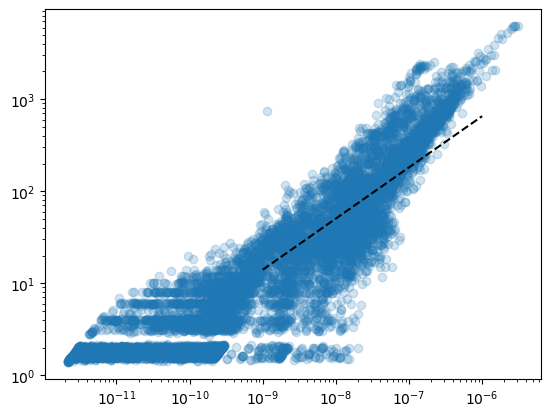

In [41]:

plt.figure()
plt.scatter(beta_coef_lst[0].squeeze(),number_conc_lst[0],alpha=0.2)
plt.plot(10**lin_plt,10**lin_reg_y.squeeze(),'k--')

plt.xscale('log')
plt.yscale('log')

In [45]:
b_error = 1e-8

In [93]:
import numpy as np
import scipy.odr as odr

# --- Your original data prep ---
lst_idx = 0
b_raw = beta_coef_lst[lst_idx].squeeze()[::2]
b_fit = np.log10(b_raw)
y_fit = np.log10(number_conc_lst[lst_idx].squeeze()[::2])

# Assume `b_error` is a numpy array containing the linear uncertainties of your b data
# 1. Transform the error into log10 space
b_fit_err = b_error / (b_raw * np.log(10))

# --- OLS Fit (Used as an initial guess for ODR) ---
ones_fit = np.ones(b_fit.shape)
lin_mat = np.stack([ones_fit, b_fit], axis=1)
# lin_fit shape is (2, 1) -> [[intercept], [slope]]
lin_fit = np.linalg.pinv(lin_mat) @ y_fit.reshape(-1, 1) 

# --- Orthogonal Distance Regression ---
# 2. Define the linear model function for ODR: f(B, x) = B[0]*x + B[1]
# Note: ODR parameters B are traditionally [slope, intercept]
def linear_func(B, x):
    return B[0] * x + B[1]

linear_model = odr.Model(linear_func)

# 3. Create a RealData object
# Provide the x and y data, and the standard deviation of x (sx).
# If you have uncertainties for y (sy), you can pass them here too.
data = odr.RealData(b_fit, y_fit, sx=b_fit_err)

# 4. Set up the ODR
# We pass the OLS slope and intercept as the initial guess (beta0) to help it converge quickly
initial_guess = [lin_fit[1][0], lin_fit[0][0]] # [slope, intercept]
myodr = odr.ODR(data, linear_model, beta0=initial_guess)

# 5. Run the regression
myoutput = myodr.run()

# The results
odr_slope, odr_intercept = myoutput.beta
print(f"ODR Slope: {odr_slope}")
print(f"ODR Intercept: {odr_intercept}")

# --- Generate your plot line ---
lin_plt = np.linspace(-9, -6, 5)
lin_reg_y = odr_slope * lin_plt + odr_intercept

ODR Slope: 0.9775730492775967
ODR Intercept: 9.335423005378145


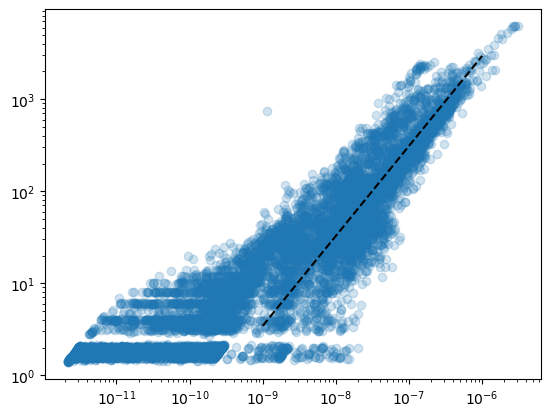

In [94]:
plt.figure()
plt.scatter(beta_coef_lst[lst_idx].squeeze(),number_conc_lst[lst_idx],alpha=0.2)
plt.plot(10**lin_plt,10**lin_reg_y.squeeze(),'k--')

plt.xscale('log')
plt.yscale('log')

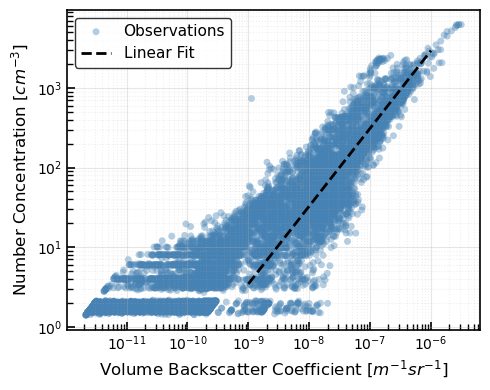

In [98]:
import matplotlib.pyplot as plt

# 1. Figure setup: Larger size and higher DPI for crispness
# plt.figure(figsize=(8, 6), dpi=150)
plt.figure(figsize=(5, 4))

# 2. Scatter plot: Adjusted colors, size, and added a label for the legend
plt.scatter(
    beta_coef_lst[lst_idx].squeeze(),
    number_conc_lst[lst_idx],
    alpha=0.4,          # Slightly increased to balance with the smaller marker size
    s=25,               # Explicit marker size
    color='steelblue',  # A more muted, professional blue than the default
    edgecolors='none',  # Removing edges reduces visual clutter when points overlap
    label='Observations'
)

# 3. Regression line: Increased visibility and added a label
plt.plot(
    10**lin_plt, 
    10**lin_reg_y.squeeze(), 
    color='black', 
    linestyle='--', 
    linewidth=2,        # Thicker line to stand out against the scatter points
    label='Linear Fit'
)

# 4. Axes scales
plt.xscale('log')
plt.yscale('log')

# 5. Descriptive Labels and Title (Update these strings to match your specific units!)
plt.xlabel('Volume Backscatter Coefficient [$m^{-1}sr^{-1}$]', fontsize=12, fontweight='medium')
plt.ylabel('Number Concentration [$cm^{-3}$]', fontsize=12, fontweight='medium')
# plt.title('Beta Coefficient vs. Number Concentration', fontsize=14, pad=15)

# 6. Gridlines: Crucial for log-log plots to help the eye track values
plt.grid(True, which='major', linestyle='-', alpha=0.3)
plt.grid(True, which='minor', linestyle=':', alpha=0.2)

# 7. Axis and Tick formatting: Thicken the border and make ticks point inward/larger
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.tick_params(axis='both', which='major', labelsize=10, length=6, width=1.2, direction='in')
ax.tick_params(axis='both', which='minor', length=4, width=1, direction='in')

# 8. Legend: Clean and positioned automatically
plt.legend(frameon=True, edgecolor='black', fontsize=11, loc='best')

# 9. Tight layout: Ensures labels and titles aren't cut off when saving
plt.tight_layout()

plt.show()

In [100]:
lst_idx = 1
b_raw = beta_coef_lst[lst_idx].squeeze()[::2]
b_fit = np.log10(b_raw)

reg_conc = odr_slope * b_fit + odr_intercept




(0.0, 200.0)

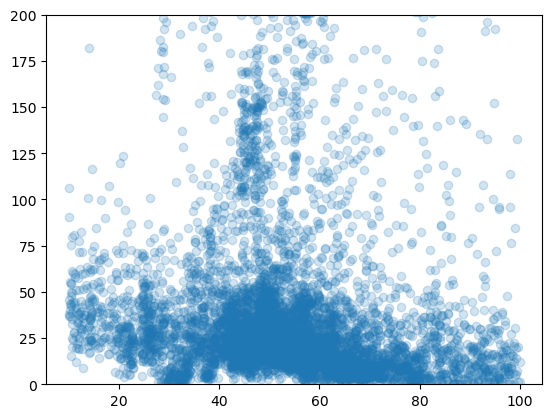

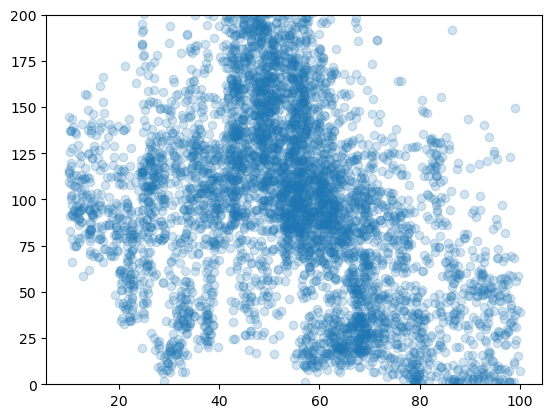

In [101]:
rhum = aircraft_vars_dct['RHUM'][lst_idx][::2].copy()
rhum[np.where(rhum > 100)] = np.nan
rhum[np.where(rhum < 10)] = np.nan
plt.figure()
plt.scatter(rhum,10**reg_conc,alpha=0.2)
# plt.yscale('log')
plt.ylim([0,200])

plt.figure()
# plt.scatter(rhum,10**reg_conc,alpha=0.2)
plt.scatter(rhum,number_conc_lst[lst_idx].squeeze()[::2],alpha=0.2)
# plt.yscale('log')
plt.ylim([0,200])

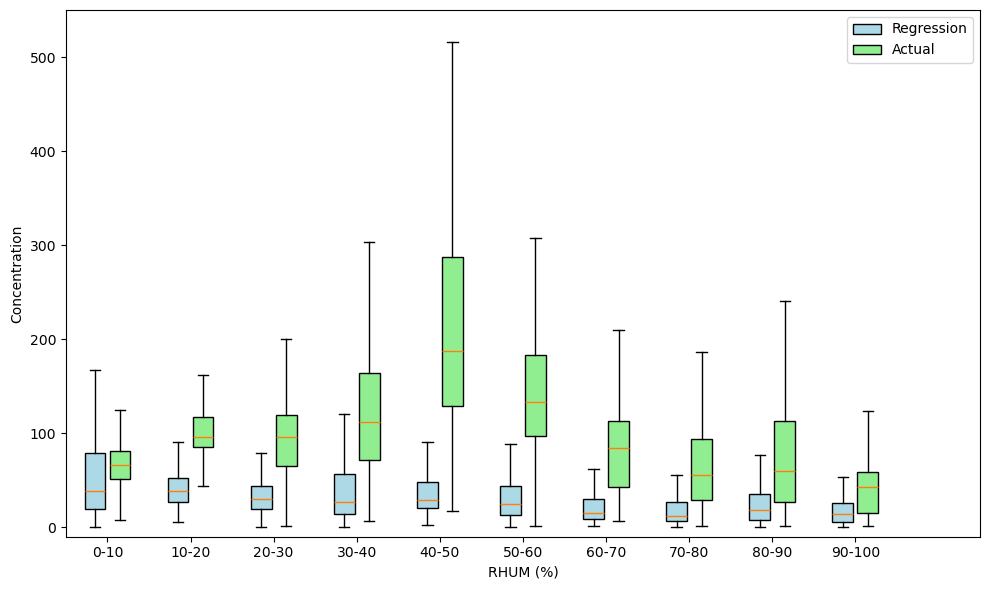

In [105]:
import numpy as np
import matplotlib.pyplot as plt

rhum = aircraft_vars_dct['RHUM'][lst_idx][::2].copy()

# --- 1. Define Variables and Clean NaNs ---
# Extract your y-variables
y1 = 10**reg_conc
y2 = number_conc_lst[lst_idx].squeeze()[::2]

# Create a boolean mask of valid (non-NaN) rhum values
valid_mask = ~np.isnan(rhum)

# Apply the mask to x and both y arrays so they stay aligned
rhum_clean = rhum[valid_mask]
y1_clean = y1[valid_mask]
y2_clean = y2[valid_mask]

# --- 2. Bin the Data ---
# Create bins for RHUM (e.g., 10 to 100 in steps of 10)
bins = np.arange(0, 110, 10) 
bin_centers = (bins[:-1] + bins[1:]) / 2

# Group the y-data into lists based on which RHUM bin they fall into
y1_binned = [y1_clean[(rhum_clean >= bins[i]) & (rhum_clean < bins[i+1])] for i in range(len(bins)-1)]
y2_binned = [y2_clean[(rhum_clean >= bins[i]) & (rhum_clean < bins[i+1])] for i in range(len(bins)-1)]

# --- 3. Plotting ---
plt.figure(figsize=(10, 6))

# Define box widths and an offset so the two sets of boxes don't overlap
box_width = 2.5
offset = 1.5 

# Plot the first dataset (Predicted/Regressed) shifted slightly left
bp1 = plt.boxplot(
    y1_binned, 
    positions=bin_centers - offset, 
    widths=box_width, 
    patch_artist=True,          # Allows us to fill the boxes with color
    boxprops=dict(facecolor='lightblue'),
    showfliers=False            # Optional: hides outliers for a cleaner look in the 0-200 range
)

# Plot the second dataset (Actual) shifted slightly right
bp2 = plt.boxplot(
    y2_binned, 
    positions=bin_centers + offset, 
    widths=box_width, 
    patch_artist=True, 
    boxprops=dict(facecolor='lightgreen'),
    showfliers=False
)

# --- 4. Formatting ---
plt.xlim([0, 110])
plt.ylim([-10, 550]) # Kept from your original code
plt.xlabel('RHUM (%)')
plt.ylabel('Concentration')

# Fix the x-ticks so they align with the bin centers rather than the offsets
plt.xticks(bin_centers, [f"{int(b)}-{int(b+10)}" for b in bins[:-1]])

# Add a legend using the boxes we just created
plt.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Regression', 'Actual'], loc='upper right')

plt.tight_layout()
plt.show()

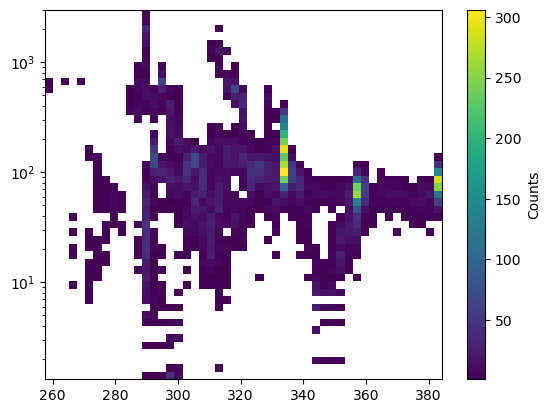

In [79]:
# import numpy as np
# import matplotlib.pyplot as plt

rhum = aircraft_vars_dct['THETA'][lst_idx][::2].copy()
# rhum[np.where(rhum > 100)] = np.nan
# rhum[np.where(rhum < 10)] = np.nan

# Extract your variables to make the plotting call cleaner
x_data = rhum
y_data = number_conc_lst[lst_idx].squeeze()[::2]
# y_data = 10**reg_conc

plt.figure()

# 1. Define the number of bins you want (e.g., a 50x50 grid)
num_bins = 50

# 2. Create linear bins for the x-axis and log bins for the y-axis
# (Note: y_data must be strictly > 0 for log10 to work)
x_bins = np.linspace(np.nanmin(x_data), np.nanmax(x_data), num_bins)
y_bins = np.logspace(np.nanmin(np.log10(y_data)), np.nanmax(np.log10(y_data)), num_bins)

# 3. Plot the 2D histogram
# `cmap` sets the color map (viridis, plasma, inferno, etc. are good for density)
# `cmin=1` makes empty bins transparent instead of drawing them as the lowest color
h, xedges, yedges, im = plt.hist2d(
    x_data, 
    y_data, 
    bins=[x_bins, y_bins], 
    cmap='viridis',
    cmin=1 
)

# 4. Set the y-axis to display logarithmically
plt.yscale('log')

# 5. Add a colorbar so you can interpret the density/counts
plt.colorbar(im, label='Counts')

plt.show()

In [58]:
np.nanmax(aircraft_vars_dct['RHUM'][lst_idx][::2])

2688.6084

In [11]:
ds

<xarray.Dataset>
Dimensions:                 (Time: 25501, sps1: 1, Vector129: 129,
                             Vector257: 257, Vector31: 31, Vector100: 100,
                             interarrival_endpoints: 41)
Coordinates:
  * Time                    (Time) datetime64[ns] 2018-01-23T23:10:00 ... 201...
  * interarrival_endpoints  (interarrival_endpoints) float32 1e-07 ... 10.0
Dimensions without coordinates: sps1, Vector129, Vector257, Vector31, Vector100
Data variables: (12/249)
    A2DCA_RWOI              (Time, sps1, Vector129) float32 ...
    A2DCR_RWOI              (Time, sps1, Vector129) float32 ...
    A2DSA_2H                (Time, sps1, Vector257) float32 ...
    A2DSA_2V                (Time, sps1, Vector257) float32 ...
    A2DSR_2H                (Time, sps1, Vector257) float32 ...
    A2DSR_2V                (Time, sps1, Vector257) float32 ...
    ...                      ...
    WIC                     (Time) float32 ...
    WOW_A                   (Time) float32 ...
    WS                      (Time) float32 ...
    WSC                     (Time) float32 ...
    XICNC                   (Time) float32 ...
    ZERO                    (Time) float32 ...
Attributes: (12/40)
    institution:                   NCAR Research Aviation Facility
    Address:                       P.O. Box 3000, Boulder, CO 80307-3000
    Phone:                         (303) 497-1030
    creator_url:                   http://www.eol.ucar.edu
    creator_email:                 codiac at ucar.edu
    Conventions:                   NCAR-RAF/nimbus
    ...                            ...
    landmarks:                     39.9088 -105.117 jeffco
    Categories:                    Position,Thermodynamic,Aircraft State,Atmo...
    time_coverage_start:           2018-01-23T23:10:00 +0000
    time_coverage_end:             2018-01-24T06:15:00 +0000
    history:                       Thu May 26 09:53:22 2022: ncks -x -v A1DC_...
    NCO:                           netCDF Operators version 4.7.5 (Homepage =...

In [14]:
ds['THDG']

<xarray.DataArray 'THDG' (Time: 25501)>
[25501 values with dtype=float32]
Coordinates:
  * Time     (Time) datetime64[ns] 2018-01-23T23:10:00 ... 2018-01-24T06:15:00
Attributes:
    units:          degree_T
    long_name:      IRS Aircraft True Heading Angle
    standard_name:  platform_orientation
    valid_range:    [  0. 360.]
    actual_range:   [1.2856751e-02 3.5999997e+02]
    Category:       Aircraft State
    SampledRate:    25
    TimeLag:        -80
    TimeLagUnits:   milliseconds
    DataQuality:    Good
    modulus_range:  [  0. 360.]